# 01 — Dataset Inventory & Manifest
 **Purpose:** Scan the segmentation dataset and produce a clean CSV manifest of all
 image / JSON / segmented-image triplets.
 **This notebook does NOT:** generate masks, train models, or split data.


# 1  Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

print(f"pandas      {pd.__version__}")
print(f"PIL         {Image.__version__}")
print(f"numpy       {np.__version__}")
print(f"matplotlib  {matplotlib.__version__}")

pandas      2.3.3
PIL         10.4.0
numpy       2.4.4
matplotlib  3.10.0


# 2  Constants
 All paths are defined in one cell. Edit only here if the dataset moves.

In [2]:
IMAGE_DIR         = Path(r"D:\DIABETES\Segmentation_Dataset\Standardized_Images")
JSON_DIR          = Path(r"D:\DIABETES\Segmentation_Dataset\LabelMe_JSON")
SEGMENTED_IMG_DIR = Path(r"D:\DIABETES\Segmentation_Dataset\Img")
OUTPUT_ROOT       = Path(r"D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs")

VALID_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

# Validate mandatory source directories exist before proceeding.
for label, path in [("IMAGE_DIR", IMAGE_DIR), ("JSON_DIR", JSON_DIR)]:
    assert path.exists(), f"Source directory not found: {label} = {path}"
    print(f"OK  {label}: {path}")

if not SEGMENTED_IMG_DIR.exists():
    print(
        f"WARNING: SEGMENTED_IMG_DIR not found ({SEGMENTED_IMG_DIR}).\n"
        "         segmented_image_exists will be False for all rows."
    )
else:
    print(f"OK  SEGMENTED_IMG_DIR: {SEGMENTED_IMG_DIR}")

OK  IMAGE_DIR: D:\DIABETES\Segmentation_Dataset\Standardized_Images
OK  JSON_DIR: D:\DIABETES\Segmentation_Dataset\LabelMe_JSON
OK  SEGMENTED_IMG_DIR: D:\DIABETES\Segmentation_Dataset\Img


# 3  Create Output Folders
Only the `OUTPUT_ROOT` subtree is written to. Source folders are never touched.


In [3]:
MANIFEST_DIR     = OUTPUT_ROOT / "01_manifest"
VISUAL_AUDIT_DIR = OUTPUT_ROOT / "04_visual_audits"

for d in [OUTPUT_ROOT, MANIFEST_DIR, VISUAL_AUDIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"Ready: {d}")

Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\01_manifest
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits


# 4  Helper Functions
Each helper has a single responsibility and is smoke-tested after definition.

In [4]:
def parse_filename(image_path: Path):
    """
    Extract patient_id and image_id from a filename of the form  x_y.ext,
    where x and y are both digit strings.

    Returns (patient_id, image_id) as strings, or (None, None) on bad format.
    Example: Path('4_1.jpg') -> ('4', '1')

    Note: splits on the FIRST underscore only, so '10_3_extra.jpg' would
    return patient_id='10', image_id='3_extra' which would then fail the
    isdigit() check — correctly excluded.
    """
    stem  = image_path.stem          # e.g. '4_1'
    parts = stem.split("_", 1)       # split on the FIRST underscore only
    if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
        return parts[0], parts[1]
    return None, None


def read_image_size(image_path: Path):
    """
    Return (width, height) via PIL header-only read. No pixel data loaded.
    Returns (None, None) silently on failure.
    """
    try:
        with Image.open(image_path) as img:
            return img.size   # PIL .size is (width, height)
    except Exception:
        return None, None


def find_segmented_image(base_name: str, seg_dir: Path):
    """
    Search seg_dir for a file whose stem matches base_name,
    trying each valid image extension in VALID_IMAGE_EXTENSIONS.
    Returns the first matching Path, or None if not found.
    """
    if not seg_dir.exists():
        return None
    for ext in VALID_IMAGE_EXTENSIONS:
        candidate = seg_dir / (base_name + ext)
        if candidate.exists():
            return candidate
    return None


def count_tongue_polygons(json_path: Path):
    """
    Open a LabelMe JSON and count shapes where:
      label == 'tongue'  AND  len(points) >= 3  (minimum valid polygon).

    Returns (count: int, error_msg: str | None).
    error_msg is None on success; contains a description string on failure.
    """
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        shapes = data.get("shapes", [])
        tongue_count = sum(
            1 for s in shapes
            if s.get("label", "").strip().lower() == "tongue"
            and len(s.get("points", [])) >= 3
        )
        return tongue_count, None
    except json.JSONDecodeError as e:
        return 0, f"json_decode_error: {e}"
    except Exception as e:
        return 0, f"json_read_error: {e}"


# ---------- smoke tests ----------
assert parse_filename(Path("4_1.jpg"))   == ("4", "1"),   "parse_filename: 4_1 failed"
assert parse_filename(Path("10_3.png"))  == ("10", "3"),  "parse_filename: 10_3 failed"
assert parse_filename(Path("bad.jpg"))   == (None, None), "parse_filename: bad-format guard failed"
assert parse_filename(Path("a_1.jpg"))   == (None, None), "parse_filename: non-digit x guard failed"
print("All helper smoke tests passed.")

All helper smoke tests passed.


# 5  Scan IMAGE_DIR and Build Records
Iterates every valid image file, collects all metadata into a flat dict per row.
**No source folder is modified.**

In [5]:
records = []

image_files = sorted(
    p for p in IMAGE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTENSIONS
)
print(f"Found {len(image_files)} image file(s) in IMAGE_DIR.")

for idx, img_path in enumerate(image_files):

    base_name = img_path.stem             # e.g. '4_1'
    sample_id = f"{idx:05d}_{base_name}"  # e.g. '00000_4_1' — unique and sortable

    # --- (a) filename format ---
    patient_id, image_id = parse_filename(img_path)
    bad_format = (patient_id is None)

    # --- (b) JSON pairing ---
    json_path   = JSON_DIR / (base_name + ".json")
    json_exists = json_path.exists()

    # --- (c) segmented image ---
    seg_path   = find_segmented_image(base_name, SEGMENTED_IMG_DIR)
    seg_exists = (seg_path is not None)

    # --- (d) image dimensions ---
    img_w, img_h = read_image_size(img_path)
    img_read_err = (img_w is None)

    # --- (e) tongue polygon count ---
    tongue_count    = 0
    json_error_flag = False
    if json_exists:
        tongue_count, json_err_msg = count_tongue_polygons(json_path)
        json_error_flag = (json_err_msg is not None)
    has_valid_tongue = (tongue_count > 0)

    # --- (f) usability decision (priority order is intentional) ---
    if bad_format:
        exclusion_reason = "bad_filename_format"
        usable = False
    elif img_read_err:
        exclusion_reason = "image_read_error"
        usable = False
    elif json_error_flag:
        exclusion_reason = "json_read_error"
        usable = False
    elif not json_exists:
        exclusion_reason = "missing_json"
        usable = False
    elif not has_valid_tongue:
        exclusion_reason = "no_tongue_polygon"
        usable = False
    else:
        exclusion_reason = "none"
        usable = True

    records.append({
        "sample_id"                 : sample_id,
        "patient_id"                : patient_id,
        "image_id"                  : image_id,
        "image_path"                : str(img_path),
        "json_path"                 : str(json_path),
        "segmented_image_path"      : str(seg_path) if seg_exists else "",
        "image_filename"            : img_path.name,
        "json_filename"             : json_path.name,
        "segmented_image_filename"  : seg_path.name if seg_exists else "",
        "image_width"               : img_w,
        "image_height"              : img_h,
        "json_exists"               : json_exists,
        "segmented_image_exists"    : seg_exists,
        "tongue_shape_count"        : tongue_count,
        "has_valid_tongue_polygon"  : has_valid_tongue,
        "usable_for_mask_generation": usable,
        "exclusion_reason"          : exclusion_reason,
    })

print(f"Scan complete — {len(records)} records built.")

Found 5267 image file(s) in IMAGE_DIR.
Scan complete — 5267 records built.


# 6  Build DataFrame & Validate Schema

In [6]:
EXPECTED_COLUMNS = [
    "sample_id", "patient_id", "image_id",
    "image_path", "json_path", "segmented_image_path",
    "image_filename", "json_filename", "segmented_image_filename",
    "image_width", "image_height",
    "json_exists", "segmented_image_exists",
    "tongue_shape_count", "has_valid_tongue_polygon",
    "usable_for_mask_generation", "exclusion_reason",
]

df = pd.DataFrame(records, columns=EXPECTED_COLUMNS)

assert list(df.columns) == EXPECTED_COLUMNS, "Column mismatch — schema broken."
assert df["sample_id"].is_unique, "Duplicate sample_ids — check image filenames."

print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (5267, 17)


,sample_id,patient_id,image_id,image_path,json_path,segmented_image_path,image_filename,json_filename,segmented_image_filename,image_width,image_height,json_exists,segmented_image_exists,tongue_shape_count,has_valid_tongue_polygon,usable_for_mask_generation,exclusion_reason
0,00000_1000_1,1000,1,D:\DIABETES\Segmentation_Dataset\Standardized_...,D:\DIABETES\Segmentation_Dataset\LabelMe_JSON\...,D:\DIABETES\Segmentation_Dataset\Img\1000_1.png,1000_1.jpg,1000_1.json,1000_1.png,512,512,True,True,1,True,True,none
1,00001_1000_2,1000,2,D:\DIABETES\Segmentation_Dataset\Standardized_...,D:\DIABETES\Segmentation_Dataset\LabelMe_JSON\...,D:\DIABETES\Segmentation_Dataset\Img\1000_2.png,1000_2.jpg,1000_2.json,1000_2.png,512,512,True,True,1,True,True,none
2,00002_1001_1,1001,1,D:\DIABETES\Segmentation_Dataset\Standardized_...,D:\DIABETES\Segmentation_Dataset\LabelMe_JSON\...,D:\DIABETES\Segmentation_Dataset\Img\1001_1.png,1001_1.jpg,1001_1.json,1001_1.png,512,512,True,True,1,True,True,none
3,00003_1001_2,1001,2,D:\DIABETES\Segmentation_Dataset\Standardized_...,D:\DIABETES\Segmentation_Dataset\LabelMe_JSON\...,D:\DIABETES\Segmentation_Dataset\Img\1001_2.png,1001_2.jpg,1001_2.json,1001_2.png,512,512,True,True,1,True,True,none
4,00004_1002_1,1002,1,D:\DIABETES\Segmentation_Dataset\Standardized_...,D:\DIABETES\Segmentation_Dataset\LabelMe_JSON\...,D:\DIABETES\Segmentation_Dataset\Img\1002_1.png,1002_1.jpg,1002_1.json,1002_1.png,512,512,True,True,1,True,True,none


# 7  Save Manifest CSV

In [7]:
MANIFEST_SAVE_PATH = MANIFEST_DIR / "segmentation_master_manifest.csv"
df.to_csv(MANIFEST_SAVE_PATH, index=False)
print(f"Manifest saved -> {MANIFEST_SAVE_PATH}")
assert MANIFEST_SAVE_PATH.exists(), "ERROR: manifest file was not created."

Manifest saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\01_manifest\segmentation_master_manifest.csv


# 8  Summary Statistics
Check these numbers for dataset integrity issues before running Notebook 2.
If missing_json or no_tongue_polygon counts are unexpectedly high,
investigate before proceeding.

In [8]:
total       = len(df)
n_usable    = int(df["usable_for_mask_generation"].sum())
n_miss_json = int((df["exclusion_reason"] == "missing_json").sum())
n_no_tongue = int((df["exclusion_reason"] == "no_tongue_polygon").sum())
n_bad_fmt   = int((df["exclusion_reason"] == "bad_filename_format").sum())
n_img_err   = int((df["exclusion_reason"] == "image_read_error").sum())
n_json_err  = int((df["exclusion_reason"] == "json_read_error").sum())

usable_df        = df[df["usable_for_mask_generation"]]
n_patients       = usable_df["patient_id"].nunique()
imgs_per_patient = (
    usable_df.groupby("patient_id").size()
    if n_patients > 0
    else pd.Series([], dtype=int)
)

print("=" * 52)
print(f"  Total images scanned         : {total}")
print(f"  Usable for mask generation   : {n_usable}")
print(f"  Excluded - missing JSON      : {n_miss_json}")
print(f"  Excluded - no tongue polygon : {n_no_tongue}")
print(f"  Excluded - bad filename fmt  : {n_bad_fmt}")
print(f"  Excluded - image read error  : {n_img_err}")
print(f"  Excluded - JSON read error   : {n_json_err}")
print("-" * 52)
print(f"  Unique patients (usable)     : {n_patients}")
if len(imgs_per_patient) > 0:
    print(f"  Min images / patient         : {imgs_per_patient.min()}")
    print(f"  Max images / patient         : {imgs_per_patient.max()}")
    print(f"  Mean images / patient        : {imgs_per_patient.mean():.2f}")
else:
    print("  (no usable samples found)")
print("=" * 52)

  Total images scanned         : 5267
  Usable for mask generation   : 5265
  Excluded - missing JSON      : 0
  Excluded - no tongue polygon : 0
  Excluded - bad filename fmt  : 2
  Excluded - image read error  : 0
  Excluded - JSON read error   : 0
----------------------------------------------------
  Unique patients (usable)     : 4641
  Min images / patient         : 1
  Max images / patient         : 4
  Mean images / patient        : 1.13


# 9  Visual Audit — 12 Random Usable Samples
Two columns per row: **original image** | **pre-existing segmented image** (placeholder if absent).
Confirms filename pairing at a glance before mask generation.

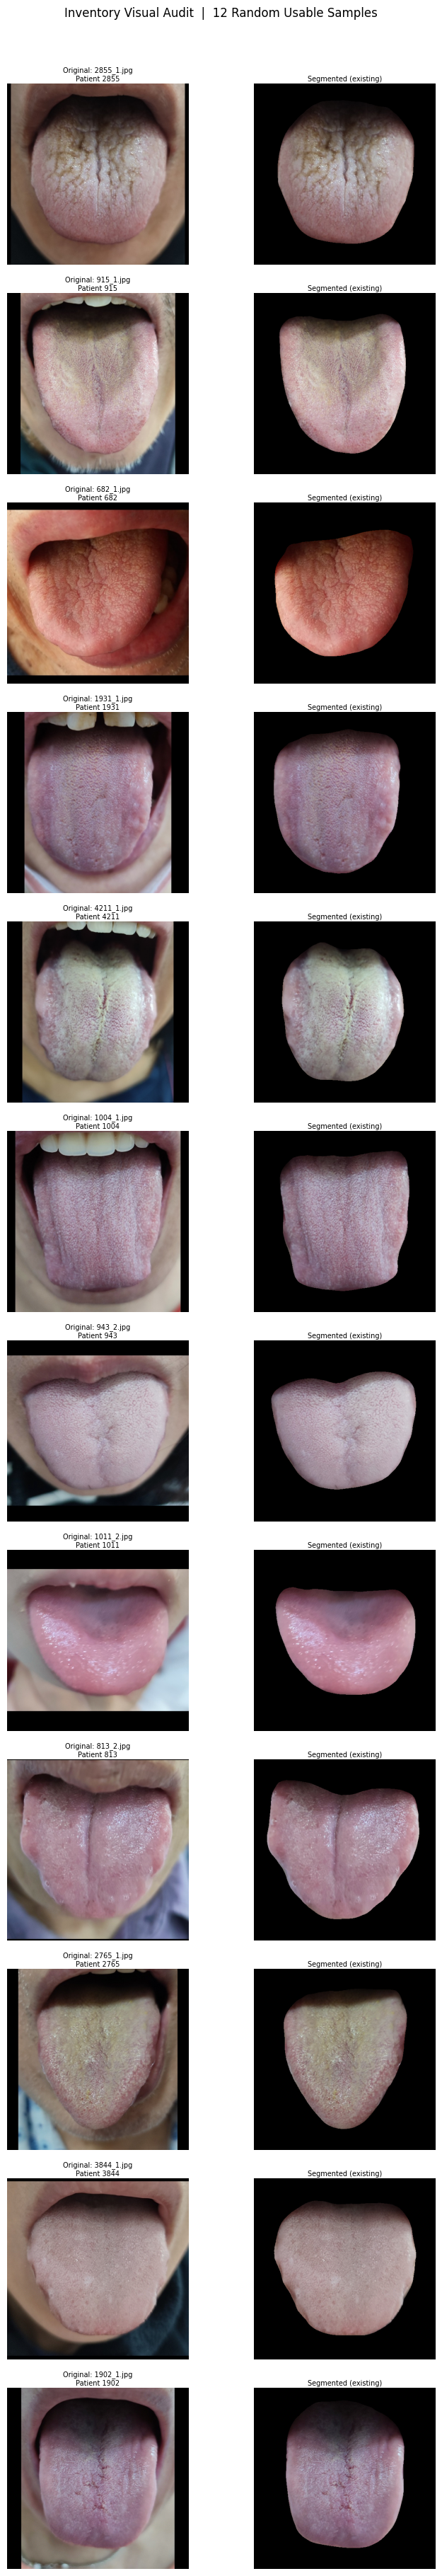

Visual audit saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits\01_inventory_visual_audit.png


In [9]:
AUDIT_SAVE_PATH = VISUAL_AUDIT_DIR / "01_inventory_visual_audit.png"

usable_rows = df[df["usable_for_mask_generation"]].reset_index(drop=True)

if len(usable_rows) == 0:
    print("No usable samples found — visual audit skipped.")
else:
    n_samples = min(12, len(usable_rows))
    sampled   = usable_rows.sample(n=n_samples, random_state=42).reset_index(drop=True)

    fig, axes = plt.subplots(n_samples, 2, figsize=(8, n_samples * 3),
                              squeeze=False)

    for i, row in sampled.iterrows():

        # --- left column: original image ---
        ax_orig = axes[i, 0]
        try:
            ax_orig.imshow(np.array(Image.open(row["image_path"])))
        except Exception as e:
            ax_orig.text(0.5, 0.5, f"Load error:\n{e}",
                         ha="center", va="center", color="red",
                         transform=ax_orig.transAxes, fontsize=7)
        ax_orig.set_title(
            f"Original: {row['image_filename']}\nPatient {row['patient_id']}",
            fontsize=7, pad=3)
        ax_orig.axis("off")

        # --- right column: segmented image or placeholder ---
        ax_seg = axes[i, 1]
        if row["segmented_image_exists"]:
            try:
                ax_seg.imshow(np.array(Image.open(row["segmented_image_path"])))
                ax_seg.set_title("Segmented (existing)", fontsize=7, pad=3)
            except Exception as e:
                ax_seg.text(0.5, 0.5, f"Load error:\n{e}",
                            ha="center", va="center", color="red",
                            transform=ax_seg.transAxes, fontsize=7)
                ax_seg.set_title("Segmented (load error)", fontsize=7, pad=3)
        else:
            ax_seg.set_facecolor("#111111")
            ax_seg.text(0.5, 0.5, "No segmented image",
                        ha="center", va="center", color="gray",
                        transform=ax_seg.transAxes, fontsize=8)
            ax_seg.set_title("Segmented (unavailable)", fontsize=7, pad=3)
        ax_seg.axis("off")

    fig.suptitle(
        f"Inventory Visual Audit  |  {n_samples} Random Usable Samples",
        fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(AUDIT_SAVE_PATH, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Visual audit saved -> {AUDIT_SAVE_PATH}")

# Notebook Complete

 | Output | Location |
 |--------|----------|
 | Master manifest | `01_manifest/segmentation_master_manifest.csv` |
 | Visual audit    | `04_visual_audits/01_inventory_visual_audit.png` |

 **Source folders were not modified.**